In [1]:
%pip install ipywidgets

## UK Road Accidents 2019 — Project Workflow

Phase 0 — Setup & Data Inspection
- Import libraries
- Load the 3 CSV files
- Inspect shape, dtypes, head
- Check for nulls, duplicates, sentinel values (-1, 99)
- Merge the 3 datasets on Accident_Index


Phase 1 — EDA (Q1, Q2, Q3)
- Feature Engineering
- Extract Hour from Time
- Map Day_of_Week codes to day names
- Create motorcycle CC categories from Engine_Capacity_(CC)

Q1 — General accident patterns
- Accidents by hour of day
- Accidents by day of week
- Heatmap: hour vs day

Q2 — Motorbike accidents

- Filter motorcycle vehicle types
- Accidents by CC group, hour, and day
- Compare across the 3 CC categories

Q3 — Pedestrian accidents

- Filter pedestrian casualties
- Accidents by hour and day
- Age distribution of pedestrian casualties


Phase 2 — Association Rule Mining (Q4)

- Select relevant categorical variables
- One-hot encode → build transaction matrix
- Run Apriori algorithm
- Filter rules where consequent = high severity
- Rank by lift and confidence
- Visualise and interpret top rules


Phase 3 — Spatial Clustering (Q5)

- Filter to Hull / Humberside / East Riding
- Run K-Means (use Elbow Method to pick K)
- Run DBSCAN (finds hotspots + flags outliers)
- Map the clusters
- Interpret what each cluster reveals


Phase 4 — Time Series Forecasting by Police Force (Q6)

- Choose 3 police forces
- Aggregate to weekly accident counts (2017–2019)
- Train on 2017–2018, forecast 2019
- Build SARIMA model per force
- Build Prophet model per force
- Compare predictions vs actual 2019 data


Phase 5 — Hull LSOA Daily Forecast (Q7)

- Identify top 30 Hull LSOAs by Q1 2019 accidents
- Aggregate daily counts for Jan–Jun 2019
- Forecast daily accidents for July
- Use SARIMA and/or Prophet
Visualise forecast with confidence intervals
- 

Phase 6 — Report & Recommendations

- One section per question with charts + findings
- Minimum 5 policy recommendations for the DfT
- Executive summary and conclusion

In [2]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from mlxtend.frequent_patterns import apriori, association_rules
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet 


In [3]:
# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8')

In [4]:
# Loading datasets
accidents  = pd.read_csv('Road Safety Data - Accidents 2019.csv')
casualties = pd.read_csv('Road Safety Data - Casualties 2019.csv')
vehicles   = pd.read_csv('Road Safety Data- Vehicles 2019.csv')

print("Accidents: ", accidents.shape)
print("Casualties:", casualties.shape)
print("Vehicles:  ", vehicles.shape)

C:\Users\odebi\AppData\Local\Temp\ipykernel_8600\405483934.py:2: DtypeWarning: Columns (0,31) have mixed types. Specify dtype option on import or set low_memory=False.
  accidents  = pd.read_csv('Road Safety Data - Accidents 2019.csv')
C:\Users\odebi\AppData\Local\Temp\ipykernel_8600\405483934.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  casualties = pd.read_csv('Road Safety Data - Casualties 2019.csv')


Accidents:  (117536, 32)
Casualties: (153158, 16)
Vehicles:   (216381, 23)


C:\Users\odebi\AppData\Local\Temp\ipykernel_8600\405483934.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  vehicles   = pd.read_csv('Road Safety Data- Vehicles 2019.csv')


## Data Cleaning

In [5]:
# Inspect Each Dataset
print("=== ACCIDENTS ===")
display(accidents.head(3))
display(accidents.dtypes)

print("\n=== CASUALTIES ===")
display(casualties.head(3))
display(casualties.dtypes)

print("\n=== VEHICLES ===")
display(vehicles.head(3))
display(vehicles.dtypes)

=== ACCIDENTS ===


,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,Day_of_Week,Time,Local_Authority_(District),Local_Authority_(Highway),1st_Road_Class,1st_Road_Number,Road_Type,Speed_limit,Junction_Detail,Junction_Control,2nd_Road_Class,2nd_Road_Number,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location
0,2019010128300,528218.0,180407.0,-0.153842,51.508057,1,3,2,3,18/02/2019,2,17:50,1,E09000033,3,4202,1,30,1,2,3,4202,0,5,1,1,1,0,0,1,3,E01004762
1,2019010152270,530219.0,172463.0,-0.127949,51.436208,1,3,2,1,15/01/2019,3,21:45,9,E09000022,3,23,2,30,0,-1,-1,0,-1,-1,4,1,1,0,0,1,3,E01003117
2,2019010155191,530222.0,182543.0,-0.124193,51.526795,1,3,2,1,01/01/2019,3,01:50,2,E09000007,4,504,6,30,3,4,6,0,0,0,4,1,1,0,0,1,1,E01000943


Accident_Index                                  object
Location_Easting_OSGR                          float64
Location_Northing_OSGR                         float64
Longitude                                      float64
Latitude                                       float64
Police_Force                                     int64
Accident_Severity                                int64
Number_of_Vehicles                               int64
Number_of_Casualties                             int64
Date                                            object
Day_of_Week                                      int64
Time                                            object
Local_Authority_(District)                       int64
Local_Authority_(Highway)                       object
1st_Road_Class                                   int64
1st_Road_Number                                  int64
Road_Type                                        int64
Speed_limit                                      int64
Junction_D


=== CASUALTIES ===


,Accident_Index,Vehicle_Reference,Casualty_Reference,Casualty_Class,Sex_of_Casualty,Age_of_Casualty,Age_Band_of_Casualty,Casualty_Severity,Pedestrian_Location,Pedestrian_Movement,Car_Passenger,Bus_or_Coach_Passenger,Pedestrian_Road_Maintenance_Worker,Casualty_Type,Casualty_Home_Area_Type,Casualty_IMD_Decile
0,2019010128300,1,1,1,1,58,9,3,0,0,0,0,0,9,1,2
1,2019010128300,1,2,2,2,-1,-1,3,0,0,1,0,0,9,1,5
2,2019010128300,1,3,2,2,-1,-1,3,0,0,2,0,0,9,1,5


Accident_Index                        object
Vehicle_Reference                      int64
Casualty_Reference                     int64
Casualty_Class                         int64
Sex_of_Casualty                        int64
Age_of_Casualty                        int64
Age_Band_of_Casualty                   int64
Casualty_Severity                      int64
Pedestrian_Location                    int64
Pedestrian_Movement                    int64
Car_Passenger                          int64
Bus_or_Coach_Passenger                 int64
Pedestrian_Road_Maintenance_Worker     int64
Casualty_Type                          int64
Casualty_Home_Area_Type                int64
Casualty_IMD_Decile                    int64
dtype: object


=== VEHICLES ===


,Accident_Index,Vehicle_Reference,Vehicle_Type,Towing_and_Articulation,Vehicle_Manoeuvre,Vehicle_Location-Restricted_Lane,Junction_Location,Skidding_and_Overturning,Hit_Object_in_Carriageway,Vehicle_Leaving_Carriageway,Hit_Object_off_Carriageway,1st_Point_of_Impact,Was_Vehicle_Left_Hand_Drive?,Journey_Purpose_of_Driver,Sex_of_Driver,Age_of_Driver,Age_Band_of_Driver,Engine_Capacity_(CC),Propulsion_Code,Age_of_Vehicle,Driver_IMD_Decile,Driver_Home_Area_Type,Vehicle_IMD_Decile
0,2019010128300,1,9,0,-1,-1,-1,-1,-1,-1,-1,4,-1,6,1,58,9,-1,-1,-1,2,1,2
1,2019010128300,2,9,0,-1,-1,-1,-1,-1,-1,-1,-1,-1,6,3,-1,-1,-1,-1,-1,2,1,2
2,2019010152270,1,9,0,18,-1,0,-1,-1,-1,-1,1,-1,6,2,24,5,-1,-1,-1,3,1,3


Accident_Index                      object
Vehicle_Reference                    int64
Vehicle_Type                         int64
Towing_and_Articulation              int64
Vehicle_Manoeuvre                    int64
Vehicle_Location-Restricted_Lane     int64
Junction_Location                    int64
Skidding_and_Overturning             int64
Hit_Object_in_Carriageway            int64
Vehicle_Leaving_Carriageway          int64
Hit_Object_off_Carriageway           int64
1st_Point_of_Impact                  int64
Was_Vehicle_Left_Hand_Drive?         int64
Journey_Purpose_of_Driver            int64
Sex_of_Driver                        int64
Age_of_Driver                        int64
Age_Band_of_Driver                   int64
Engine_Capacity_(CC)                 int64
Propulsion_Code                      int64
Age_of_Vehicle                       int64
Driver_IMD_Decile                    int64
Driver_Home_Area_Type                int64
Vehicle_IMD_Decile                   int64
dtype: obje

In [6]:
# Check for null values
print("=== Nulls in ACCIDENTS ===")
print(accidents.isnull().sum()[accidents.isnull().sum() > 0])

print("\n=== Nulls in CASUALTIES ===")
print(casualties.isnull().sum()[casualties.isnull().sum() > 0])

print("\n=== Nulls in VEHICLES ===")
print(vehicles.isnull().sum()[vehicles.isnull().sum() > 0])

=== Nulls in ACCIDENTS ===
Location_Easting_OSGR          28
Location_Northing_OSGR         28
Longitude                      28
Latitude                       28
Time                           63
LSOA_of_Accident_Location    5714
dtype: int64

=== Nulls in CASUALTIES ===
Series([], dtype: int64)

=== Nulls in VEHICLES ===
Series([], dtype: int64)


In [7]:
# Check for duplicates
print("Duplicate rows in accidents: ", accidents.duplicated().sum())
print("Duplicate rows in casualties:", casualties.duplicated().sum())
print("Duplicate rows in vehicles:  ", vehicles.duplicated().sum())

Duplicate rows in accidents:  0
Duplicate rows in casualties: 0
Duplicate rows in vehicles:   0


Replace Sentinel Values

NB: In UK road safety data, -1 and 99 are used as codes for "unknown" or "data missing". We replace them with NaN so they don't distort our analysis.

In [8]:
# Replace -1 and 99 with NaN across all three datasets
accidents  = accidents.replace([-1, 99], np.nan)
casualties = casualties.replace([-1, 99], np.nan)
vehicles   = vehicles.replace([-1, 99], np.nan)

print("Sentinel values replaced ✅")

Sentinel values replaced ✅


In [9]:
# Fix DataTypes
# Parse Date to datetime
accidents['Date'] = pd.to_datetime(accidents['Date'], dayfirst=True)

# Extract Hour from Time
accidents['Hour'] = pd.to_datetime(accidents['Time'], format='%H:%M', errors='coerce').dt.hour

# Map Day_of_Week codes to names (DfT coding: 1=Sunday, 2=Monday ... 7=Saturday)
day_map = {1:'Sunday', 2:'Monday', 3:'Tuesday', 4:'Wednesday',
           5:'Thursday', 6:'Friday', 7:'Saturday'}
accidents['Day_Name'] = accidents['Day_of_Week'].map(day_map)

print("Data types fixed ✅")
accidents[['Date', 'Hour', 'Day_Name']].head()

Data types fixed ✅


,Date,Hour,Day_Name
0,2019-02-18,17.0,Monday
1,2019-01-15,21.0,Tuesday
2,2019-01-01,1.0,Tuesday
3,2019-01-01,1.0,Tuesday
4,2019-01-01,0.0,Tuesday


In [10]:
# Merge datasets
# Accidents + Casualties (one row per casualty)
acc_cas = accidents.merge(casualties, on='Accident_Index', how='left')

# Add Vehicles
full_df = acc_cas.merge(vehicles, on='Accident_Index', how='left')

print("Merged shape:", full_df.shape)
print("Accidents-only shape:", accidents.shape)
display(full_df.head(3))

Merged shape: (258188, 71)
Accidents-only shape: (117536, 34)


,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,Day_of_Week,Time,Local_Authority_(District),Local_Authority_(Highway),1st_Road_Class,1st_Road_Number,Road_Type,Speed_limit,Junction_Detail,Junction_Control,2nd_Road_Class,2nd_Road_Number,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,Hour,Day_Name,Vehicle_Reference_x,Casualty_Reference,Casualty_Class,Sex_of_Casualty,Age_of_Casualty,Age_Band_of_Casualty,Casualty_Severity,Pedestrian_Location,Pedestrian_Movement,Car_Passenger,Bus_or_Coach_Passenger,Pedestrian_Road_Maintenance_Worker,Casualty_Type,Casualty_Home_Area_Type,Casualty_IMD_Decile,Vehicle_Reference_y,Vehicle_Type,Towing_and_Articulation,Vehicle_Manoeuvre,Vehicle_Location-Restricted_Lane,Junction_Location,Skidding_and_Overturning,Hit_Object_in_Carriageway,Vehicle_Leaving_Carriageway,Hit_Object_off_Carriageway,1st_Point_of_Impact,Was_Vehicle_Left_Hand_Drive?,Journey_Purpose_of_Driver,Sex_of_Driver,Age_of_Driver,Age_Band_of_Driver,Engine_Capacity_(CC),Propulsion_Code,Age_of_Vehicle,Driver_IMD_Decile,Driver_Home_Area_Type,Vehicle_IMD_Decile
0,2019010128300,528218.0,180407.0,-0.153842,51.508057,1,3,2,3,2019-02-18,2,17:50,1,E09000033,3,4202.0,1,30.0,1.0,2.0,3.0,4202.0,0.0,5.0,1.0,1,1.0,0.0,0.0,1,3,E01004762,17.0,Monday,1.0,1.0,1.0,1.0,58.0,9.0,3.0,0.0,0.0,0.0,0.0,0.0,9.0,1.0,2.0,1.0,9.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,6.0,1.0,58.0,9.0,NaN,NaN,NaN,2.0,1.0,2.0
1,2019010128300,528218.0,180407.0,-0.153842,51.508057,1,3,2,3,2019-02-18,2,17:50,1,E09000033,3,4202.0,1,30.0,1.0,2.0,3.0,4202.0,0.0,5.0,1.0,1,1.0,0.0,0.0,1,3,E01004762,17.0,Monday,1.0,1.0,1.0,1.0,58.0,9.0,3.0,0.0,0.0,0.0,0.0,0.0,9.0,1.0,2.0,2.0,9.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,3.0,NaN,NaN,NaN,NaN,NaN,2.0,1.0,2.0
2,2019010128300,528218.0,180407.0,-0.153842,51.508057,1,3,2,3,2019-02-18,2,17:50,1,E09000033,3,4202.0,1,30.0,1.0,2.0,3.0,4202.0,0.0,5.0,1.0,1,1.0,0.0,0.0,1,3,E01004762,17.0,Monday,1.0,2.0,2.0,2.0,NaN,NaN,3.0,0.0,0.0,1.0,0.0,0.0,9.0,1.0,5.0,1.0,9.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,6.0,1.0,58.0,9.0,NaN,NaN,NaN,2.0,1.0,2.0


In [11]:
# Summary of dataset
print("=== Accident Severity Counts ===")
print(accidents['Accident_Severity'].value_counts())
# 1 = Fatal, 2 = Serious, 3 = Slight

print("\n=== Casualty Class Counts ===")
print(casualties['Casualty_Class'].value_counts())
# 1 = Driver, 2 = Passenger, 3 = Pedestrian

print("\n=== Date Range ===")
print("From:", accidents['Date'].min())
print("To:  ", accidents['Date'].max())

print("\n=== Basic Stats ===")
display(accidents[['Number_of_Vehicles', 'Number_of_Casualties', 'Speed_limit']].describe())


=== Accident Severity Counts ===
Accident_Severity
3    92456
2    23422
1     1658
Name: count, dtype: int64

=== Casualty Class Counts ===
Casualty_Class
1    99290
2    32098
3    21770
Name: count, dtype: int64

=== Date Range ===
From: 2019-01-01 00:00:00
To:   2019-12-31 00:00:00

=== Basic Stats ===


,Number_of_Vehicles,Number_of_Casualties,Speed_limit
count,117536.000000,117536.000000,117456.000000
mean,1.840976,1.303073,36.799142
std,0.708412,0.754369,14.036327
min,1.000000,1.000000,20.000000
25%,1.000000,1.000000,30.000000
50%,2.000000,1.000000,30.000000
75%,2.000000,1.000000,40.000000
max,17.000000,52.000000,70.000000


## Phase 1 — EDA (Q1, Q2, Q3)
- Feature Engineering
- Extract Hour from Time
- Map Day_of_Week codes to day names
- Create motorcycle CC categories from Engine_Capacity_(CC)

Q1 — General accident patterns

Q2 — Motorbike accidents

Q3 — Pedestrian accidents


In [12]:
# Feature Engineering
# Time bands
def time_band(hour):
    if 0 <= hour <= 6:    return 'Night'
    elif 7 <= hour <= 9:  return 'Morning Rush'
    elif 10 <= hour <= 15: return 'Daytime'
    elif 16 <= hour <= 18: return 'Evening Rush'
    else:                  return 'Evening'

accidents['Time_Band'] = accidents['Hour'].apply(time_band)

# Weekday vs Weekend
accidents['Week_Type'] = accidents['Day_Name'].apply(
    lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday'
)

# Ordered day list (for consistent chart ordering)
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

print("Feature engineering done ✅")
accidents[['Hour', 'Time_Band', 'Day_Name', 'Week_Type']].head()

Feature engineering done ✅


,Hour,Time_Band,Day_Name,Week_Type
0,17.0,Evening Rush,Monday,Weekday
1,21.0,Evening,Tuesday,Weekday
2,1.0,Night,Tuesday,Weekday
3,1.0,Night,Tuesday,Weekday
4,0.0,Night,Tuesday,Weekday


### Q1 — General accident patterns
- Accidents by hour of day
- Accidents by day of week
- Heatmap: hour vs day


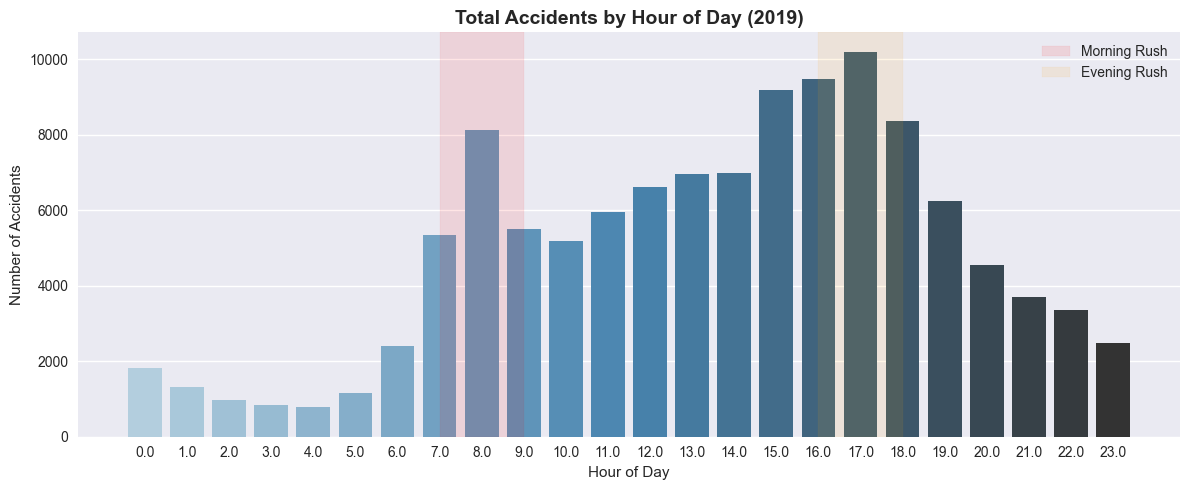

In [14]:
# Accidents by Hour of Day
fig, ax = plt.subplots(figsize=(12, 5))

hourly = accidents.groupby('Hour').size().reset_index(name='Count')

sns.barplot(data=hourly, x='Hour', y='Count', hue='Hour', palette='Blues_d', ax=ax, legend=False)
ax.set_title('Total Accidents by Hour of Day (2019)', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Accidents')
ax.axvspan(7, 9, alpha=0.1, color='red', label='Morning Rush')
ax.axvspan(16, 18, alpha=0.1, color='orange', label='Evening Rush')
ax.legend()
plt.tight_layout()
plt.show()

#### Finding
Accident frequency follows a clear bimodal distribution across the 24-hour day.
The first peak occurs between **8am and 9am**, and the largest peak between **5pm and 6pm**,
both corresponding directly to the morning and evening commuter rush hours.
Accidents fall to their lowest levels between **midnight and 6am**.

#### Explanation
The pattern is consistent with the rhythm of the working day.
Higher traffic volumes during commuter hours naturally increase the probability of collisions.
The evening peak is larger than the morning peak, likely because drivers are more fatigued
at the end of the working day and evening light conditions are deteriorating.
The near-absence of accidents in the early hours reflects minimal traffic volumes overnight.

#### Policy Implication
The Department for Transport should prioritise road safety interventions —
such as variable speed limits, increased enforcement presence, and
public transport incentives — during the 7–9am and 4–7pm windows,
particularly on high-volume urban routes.

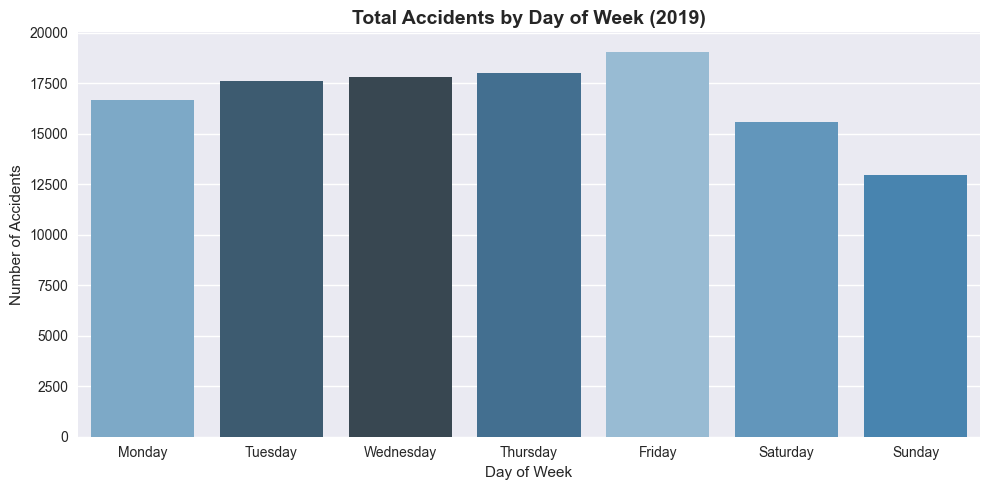

In [17]:
# Accidents by Day of Week
fig, ax = plt.subplots(figsize=(10, 5))

daily = accidents.groupby('Day_Name').size().reset_index(name='Count')

sns.barplot(data=daily, x='Day_Name', y='Count', hue='Day_Name', order=day_order, palette='Blues_d', ax=ax, legend=False)
ax.set_title('Total Accidents by Day of Week (2019)', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Accidents')
plt.tight_layout()
plt.show()

#### Finding
Accidents are broadly consistent across weekdays (Monday to Friday),
with **Friday recording the highest number of accidents** of any single day.
Saturday and Sunday both show noticeably lower accident counts compared to weekdays.

#### Explanation
The elevated weekday counts reflect the dominance of commuter traffic as the primary
driver of road accidents. Friday's peak may be attributed to a combination of factors:
higher traffic volumes as people travel for weekend leisure, end-of-week driver fatigue,
and a greater prevalence of social journeys later in the evening.
The lower weekend counts challenge the assumption that weekends are more dangerous —
overall accident frequency is lower, though severity patterns may differ.

#### Policy Implication
Friday should be treated as a high-priority day for traffic management and enforcement.
Campaign messaging around driver fatigue and journey planning could be targeted
specifically at Friday afternoon and evening travel periods.

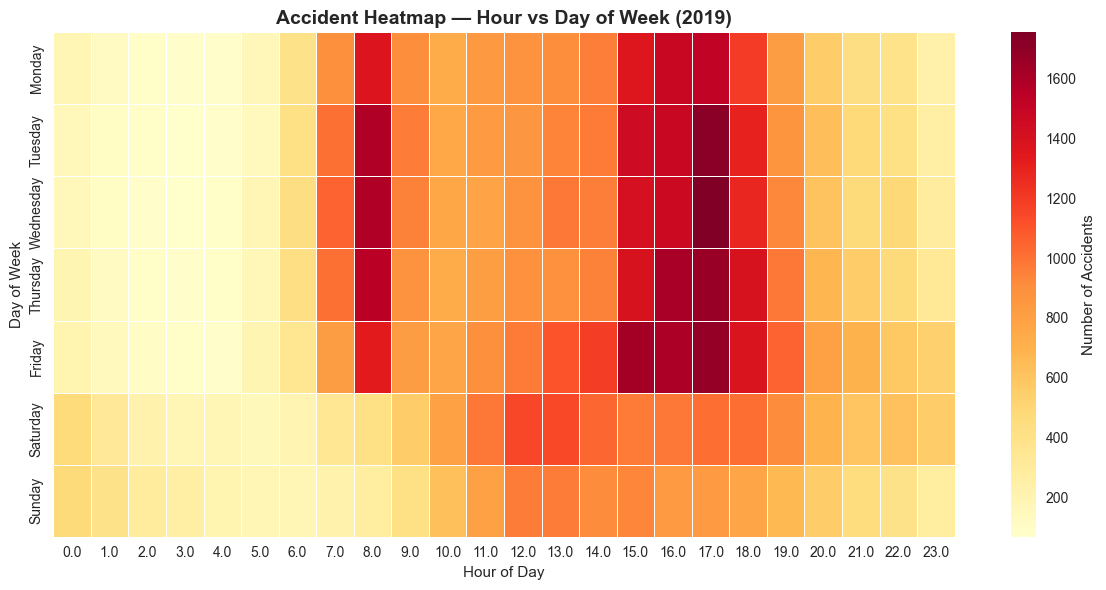

In [18]:
# Heatmap: Hour vs Day of Week
fig, ax = plt.subplots(figsize=(12, 6))

heatmap_data = accidents.groupby(['Day_Name', 'Hour']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(day_order)

sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Number of Accidents'})
ax.set_title('Accident Heatmap — Hour vs Day of Week (2019)', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.show()

#### Finding
The heatmap reveals that the highest accident concentrations occur at
**Friday between 5pm and 6pm**, followed by weekday mornings between **8am and 9am**
consistently across Monday to Friday. A secondary cluster is visible on
**Friday and Saturday nights between 10pm and midnight**, albeit at lower intensity.

#### Explanation
The Friday evening cell is the single hottest point on the heatmap, combining
peak commuter traffic with the start of weekend leisure travel — a uniquely
high-risk convergence. The consistent weekday morning band confirms the commuter
rush effect seen in Chart 1. The late Friday/Saturday night cluster is likely
linked to nightlife-related journeys, where driver impairment and fatigue
are contributing factors even at lower overall traffic volumes.

#### Policy Implication
A targeted, time-specific approach to road safety would be more effective than
blanket measures. Resources should be concentrated on Friday evenings as a
priority window. Additionally, late-night weekend enforcement — particularly
around urban centres — addresses a distinct and preventable risk cluster
that sits outside the commuter pattern.

### Q2 — Motorbike accidents

- Filter motorcycle vehicle types
- Accidents by CC group, hour, and day
- Compare across the 3 CC categories


In [19]:
# Check vehicle type codes and their counts
print(vehicles['Vehicle_Type'].value_counts().sort_index())

Vehicle_Type
1.0      17437
2.0       1489
3.0       8053
4.0       2119
5.0       5228
8.0       4696
9.0     152686
10.0       405
11.0      3902
16.0        65
17.0       423
18.0        26
19.0     12579
20.0       982
21.0      3357
22.0       250
23.0        65
90.0      1005
97.0       415
98.0       890
Name: count, dtype: int64


In [21]:
# Filter vehicles to motorcycles only
moto_codes = [2, 3, 4, 5, 23]
moto_vehicles = vehicles[vehicles['Vehicle_Type'].isin(moto_codes)].copy()

# Map codes to CC category labels
cc_map = {
    2: '<=125cc',
    3: '<=125cc',
    23: '<=125cc',
    4: '126-500cc',
    5: '>500cc'
}
moto_vehicles['CC_Category'] = moto_vehicles['Vehicle_Type'].map(cc_map)

print("Motorcycle records:", len(moto_vehicles))
print("\nCounts per CC Category:")
print(moto_vehicles['CC_Category'].value_counts())

Motorcycle records: 16954

Counts per CC Category:
CC_Category
<=125cc      9607
>500cc       5228
126-500cc    2119
Name: count, dtype: int64


In [22]:
# Merge motorcycle vehicles with accidents to get Hour, Day_Name etc.
moto_df = moto_vehicles.merge(
    accidents[['Accident_Index', 'Hour', 'Day_Name', 'Week_Type', 'Accident_Severity']],
    on='Accident_Index', how='left'
)

# Drop rows where Hour or Day_Name is missing
moto_df = moto_df.dropna(subset=['Hour', 'Day_Name'])

print("Merged motorcycle DataFrame shape:", moto_df.shape)
moto_df[['Accident_Index', 'Vehicle_Type', 'CC_Category', 'Hour', 'Day_Name']].head()

Merged motorcycle DataFrame shape: (13951, 28)


,Accident_Index,Vehicle_Type,CC_Category,Hour,Day_Name
0,2019010155225,4.0,126-500cc,0.0,Tuesday
1,2019010155254,3.0,<=125cc,14.0,Tuesday
2,2019010155255,3.0,<=125cc,15.0,Tuesday
3,2019010155263,4.0,126-500cc,13.0,Tuesday
4,2019010155276,5.0,>500cc,16.0,Tuesday


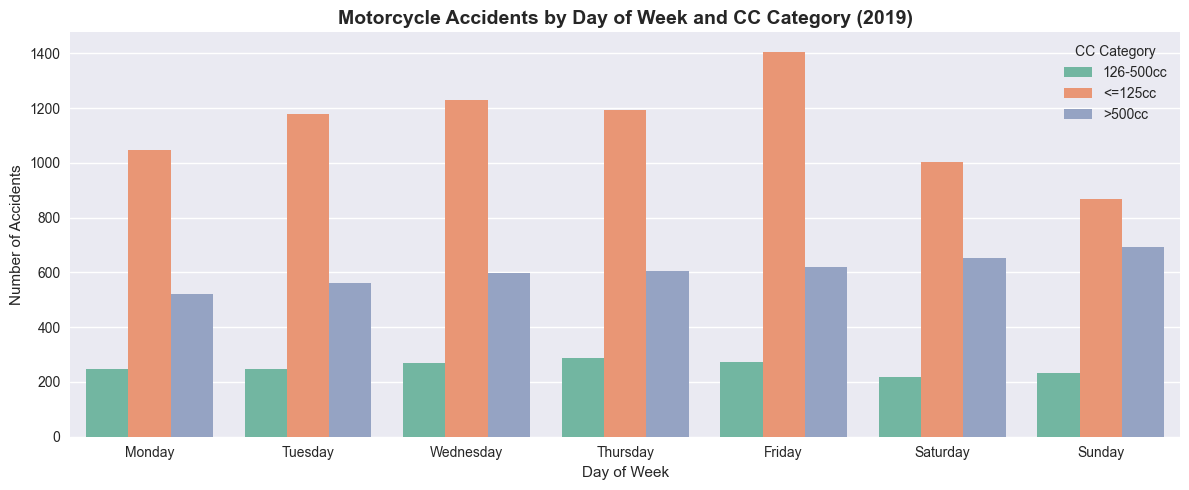

In [23]:
# Accidents by CC Category and Day of Week
fig, ax = plt.subplots(figsize=(12, 5))

moto_day = moto_df.groupby(['CC_Category', 'Day_Name']).size().reset_index(name='Count')

sns.barplot(data=moto_day, x='Day_Name', y='Count', hue='CC_Category',
            order=day_order, palette='Set2', ax=ax)

ax.set_title('Motorcycle Accidents by Day of Week and CC Category (2019)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Accidents')
ax.legend(title='CC Category')
plt.tight_layout()
plt.show()

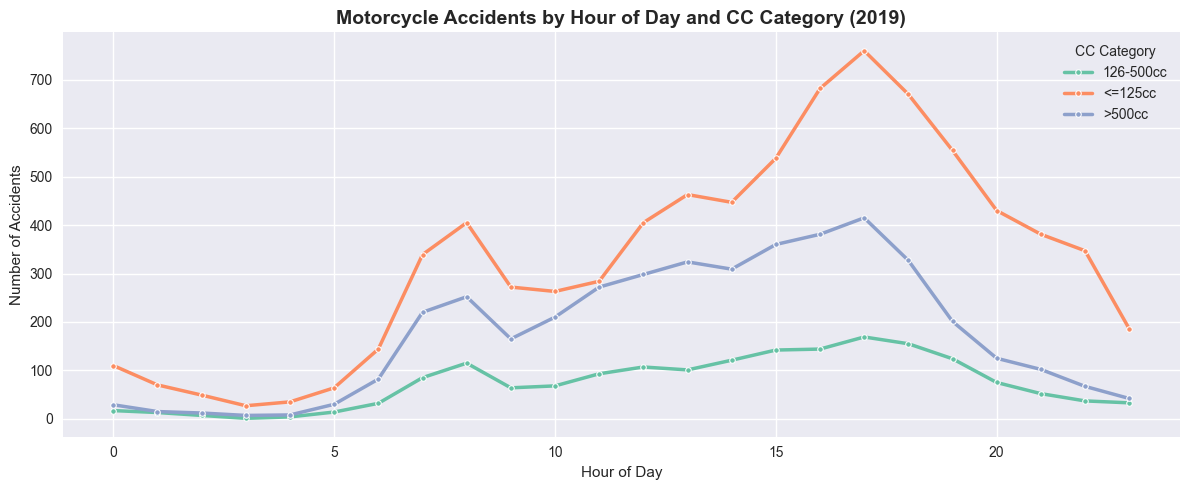

In [24]:
#  Accidents by CC Category and Hour of Day
fig, ax = plt.subplots(figsize=(12, 5))

moto_hour = moto_df.groupby(['CC_Category', 'Hour']).size().reset_index(name='Count')

sns.lineplot(data=moto_hour, x='Hour', y='Count', hue='CC_Category',
             palette='Set2', linewidth=2.5, marker='o', markersize=4, ax=ax)

ax.set_title('Motorcycle Accidents by Hour of Day and CC Category (2019)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Accidents')
ax.legend(title='CC Category')
plt.tight_layout()
plt.show()

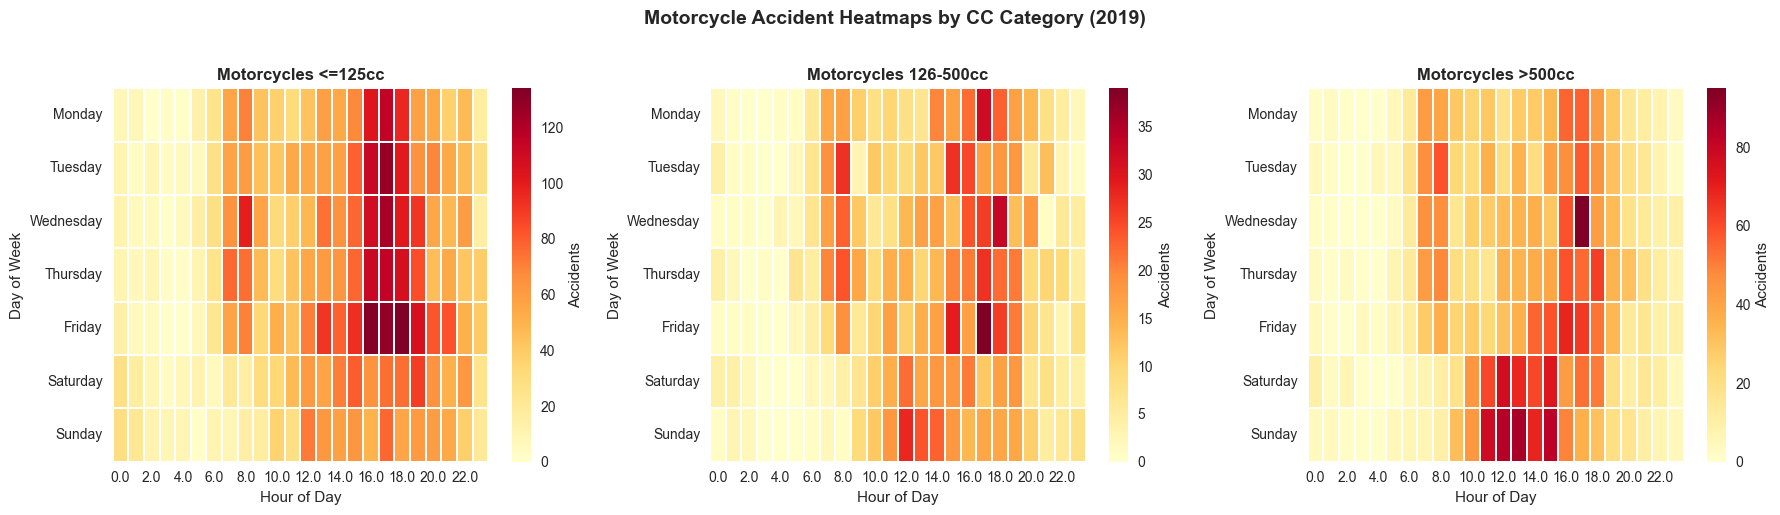

In [25]:
# Heatmaps: One Per CC Category
cc_categories = ['<=125cc', '126-500cc', '>500cc']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cc in zip(axes, cc_categories):
    subset = moto_df[moto_df['CC_Category'] == cc]
    hmap = subset.groupby(['Day_Name', 'Hour']).size().unstack(fill_value=0)
    hmap = hmap.reindex(day_order)

    sns.heatmap(hmap, cmap='YlOrRd', ax=ax, linewidths=0.3,
                cbar_kws={'label': 'Accidents'})
    ax.set_title(f'Motorcycles {cc}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Day of Week')

plt.suptitle('Motorcycle Accident Heatmaps by CC Category (2019)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Q3 — Pedestrian accidents

- Filter pedestrian casualties
- Accidents by hour and day
- Age distribution of pedestrian casualties